# Loan Approval EDA Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_sanction_test (2).csv")

## Data overview

In [3]:
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 34.5 KB


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

--> Found some null values in the dataset

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


--> Handling null values by replacing them with mode/mean:

In [7]:
df[['Gender','Self_Employed','Credit_History','Loan_Amount_Term','Dependents']].mode()

,Gender,Self_Employed,Credit_History,Loan_Amount_Term,Dependents
0,Male,No,1.0,360.0,0


In [8]:
df['LoanAmount'].mean()

np.float64(136.13259668508286)

In [9]:
df.fillna({ 'Gender': df['Gender'].mode()[0], 'Self_Employed': df['Self_Employed'].mode()[0],
            'Dependents': df['Dependents'].mode()[0], 'Credit_History' : df['Credit_History'].mode()[0],
           'Loan_Amount_Term' : df['Loan_Amount_Term'].mode()[0]
}, inplace=True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,1.0,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [10]:
df.fillna({'LoanAmount' : df['LoanAmount'].mean()},inplace=True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,1.0,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [11]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

--> As we can see we replaced missing values, now our dataset has 0 null values

--> Checking if our dataset contains duplicate rows or values

In [12]:
df.duplicated().sum()

np.int64(0)

--> Contains 0 Duplicates

# Visualization

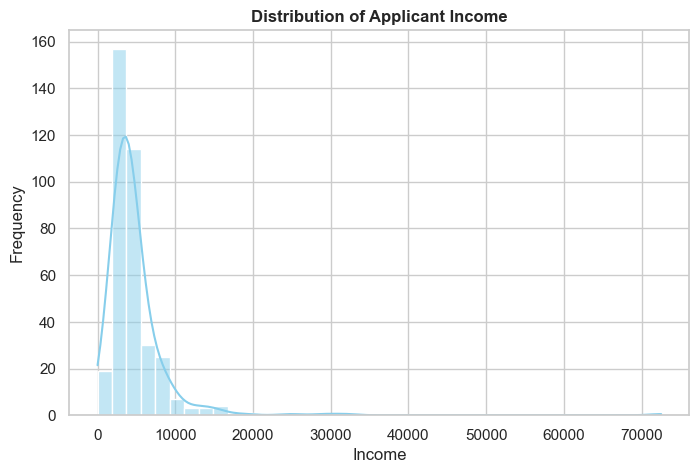

In [28]:
sns.histplot(df['ApplicantIncome'], kde=True, color='skyblue')
plt.title("Distribution of Applicant Income",fontweight="bold",fontsize="12")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

--> Most people applying for this loan have a lower income.

--> There are very few people with a very high income. This means high income applicants are rare for this specific loan.

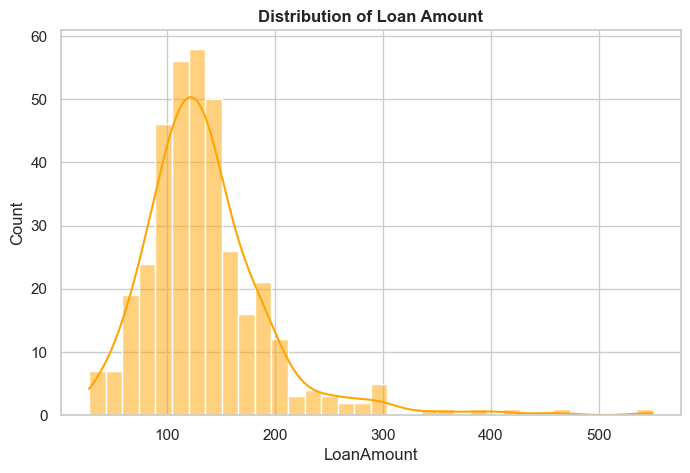

In [30]:
sns.histplot(df['LoanAmount'], kde=True, color='orange')
plt.title("Distribution of Loan Amount",fontweight="bold",fontsize="12")
plt.show()

-->  Most people are asking loan amount between 100 and 150. This means this is the most popular loan size for customers.

--> Very few people taking loans over 300. This shows that high value loans are not very common in this data.

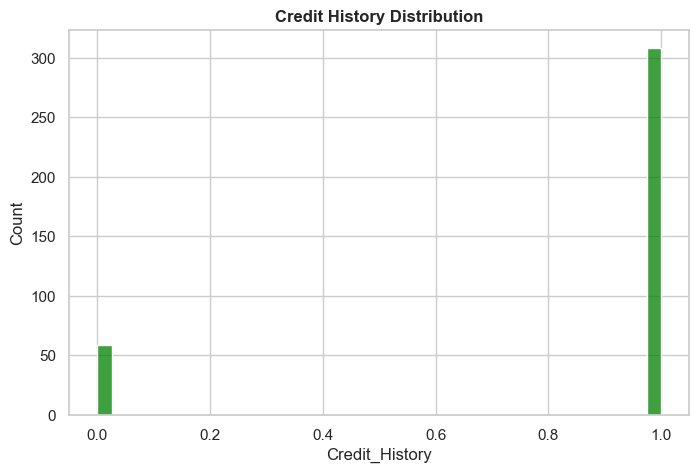

In [32]:
sns.histplot(df['Credit_History'], color='green')
plt.title("Credit History Distribution",fontweight="bold",fontsize="12")
plt.show()

--> Credit History indicating good credit history. While 0 indicating bad credit history of the applicants.

--> Most people has in this dataset has good credit history.

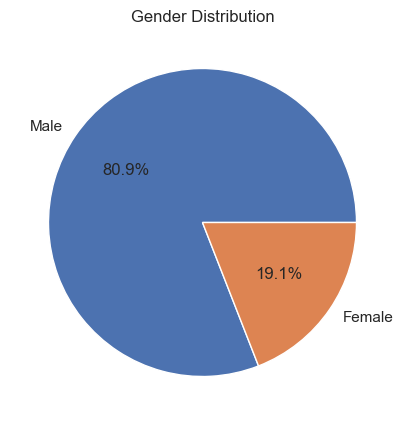

In [47]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

--> 80.9% are males.

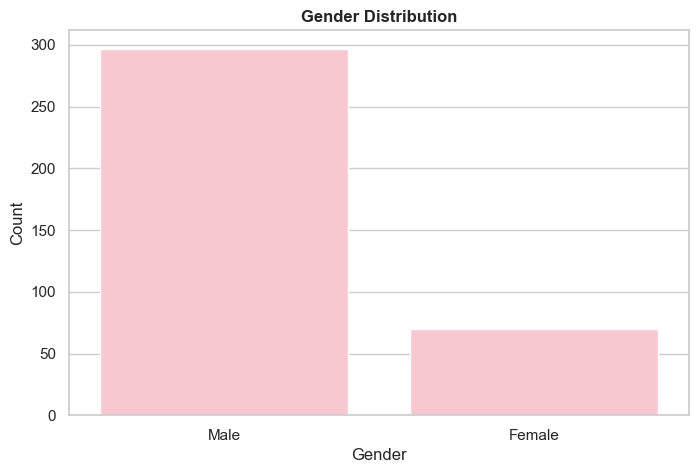

In [40]:
sns.countplot(x='Gender', data=df, color='pink')
plt.title('Gender Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

--> Male applicants are higher than the women applicants.

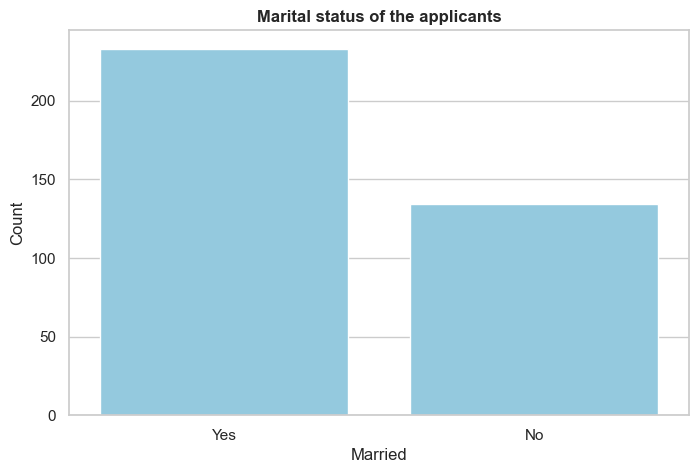

In [42]:
sns.countplot(x='Married', data=df, color='skyblue')
plt.title('Marital status of the applicants', fontsize=12, fontweight='bold')
plt.xlabel('Married')
plt.ylabel('Count')
plt.show()

--> Most of the applicants are married.

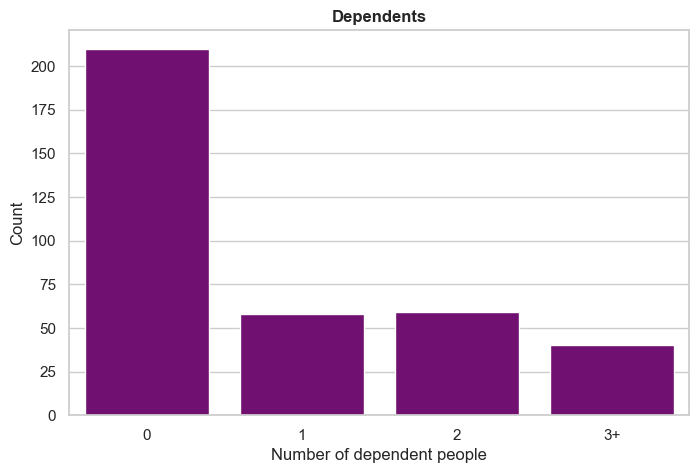

In [43]:
sns.countplot(x='Dependents', data=df, color='purple')
plt.title('Dependents', fontsize=12, fontweight='bold')
plt.xlabel('Number of dependent people')
plt.ylabel('Count')
plt.show()

--> No. of dependents on the applicants are mostly 0.

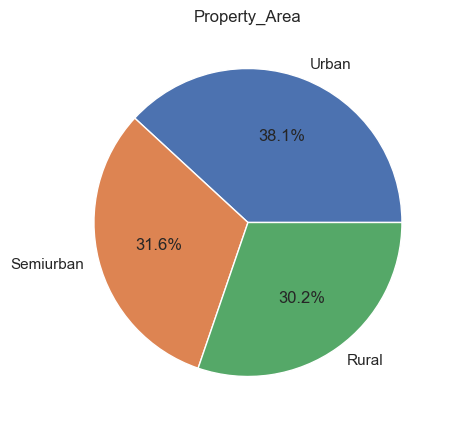

In [48]:
df['Property_Area'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Property_Area")
plt.ylabel("")
plt.show()

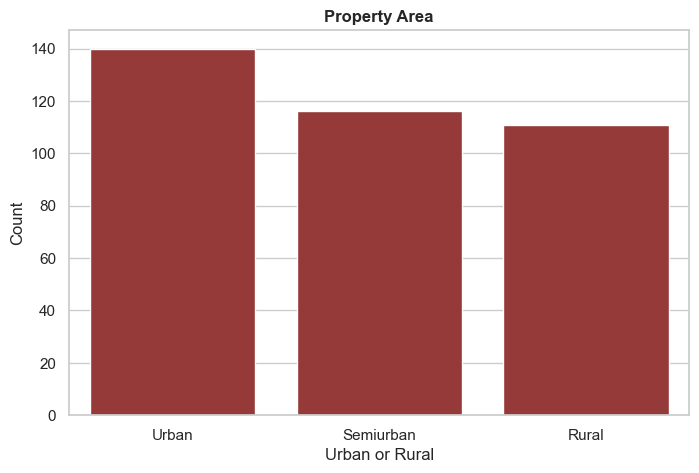

In [45]:
sns.countplot(x='Property_Area', data=df, color='brown')
plt.title('Property Area', fontsize=12, fontweight='bold')
plt.xlabel('Urban or Rural')
plt.ylabel('Count')
plt.show()

--> High number of people applying for the loan are from Urban areas.

--> Leat people are applying for the loan are from rural areas.

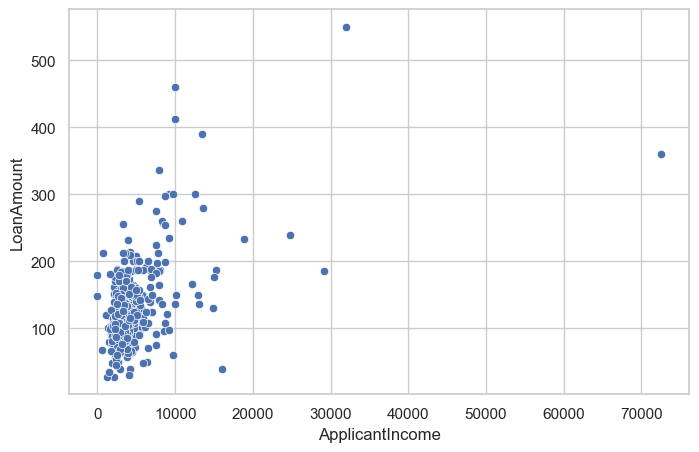

In [49]:
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount')
plt.show()

--> Most applicants have a lower income and ask for smalller loans. This shows that this group is the bank's biggest customer base.

--> There are a few extreme cases where income or loan amount are very high. As a result, these few people are very different from the average customer.

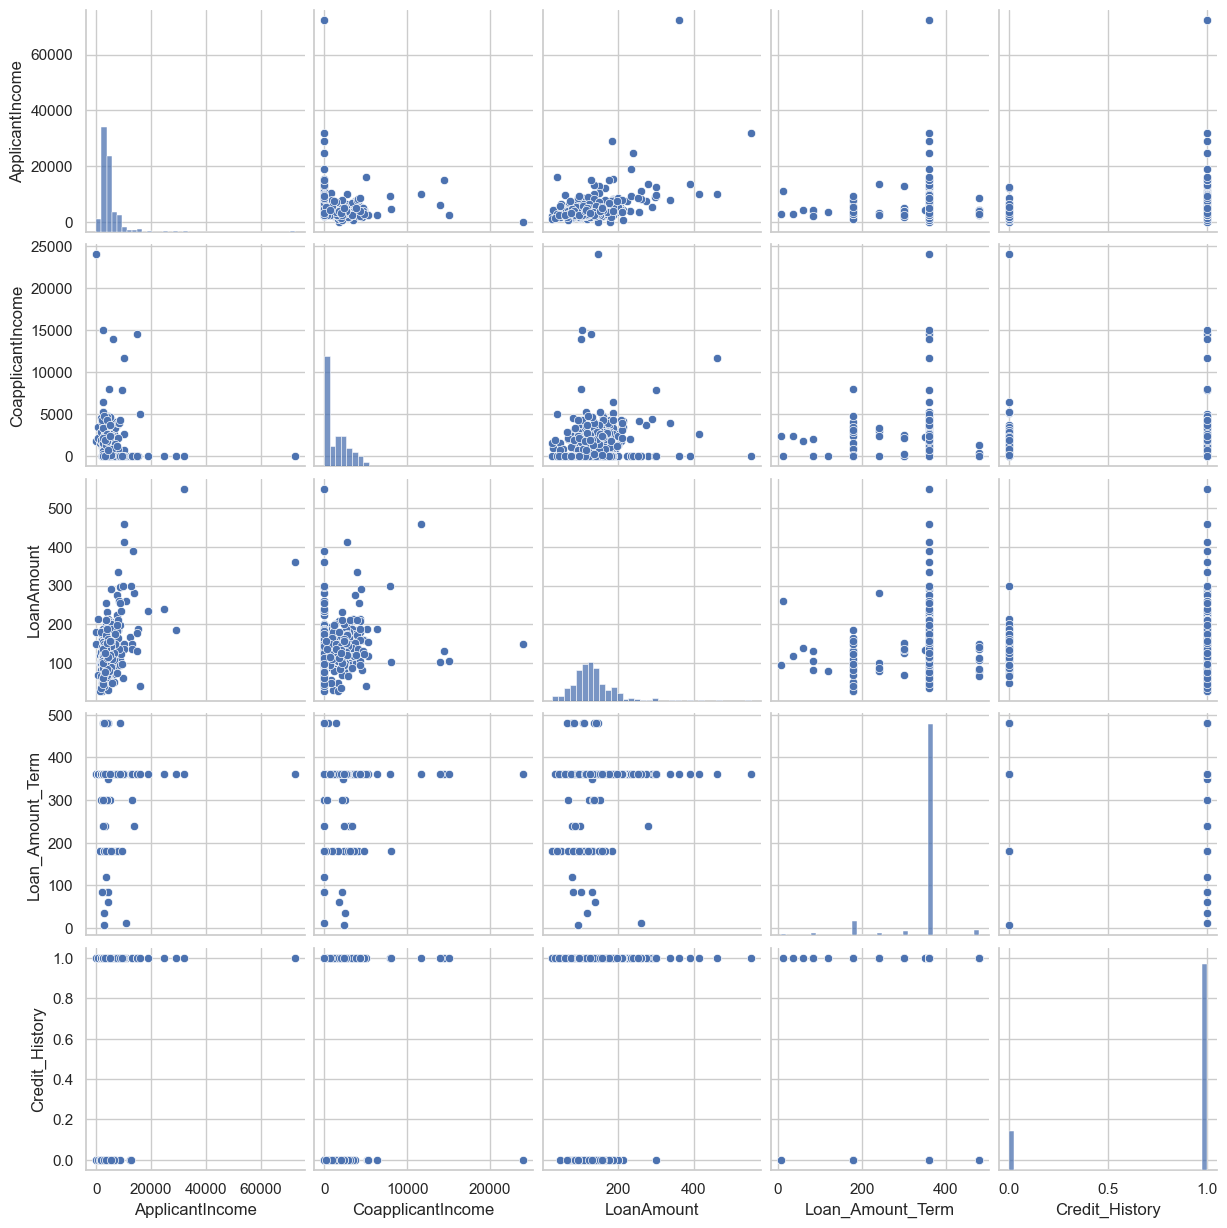

In [50]:
sns.pairplot(df)
plt.show()

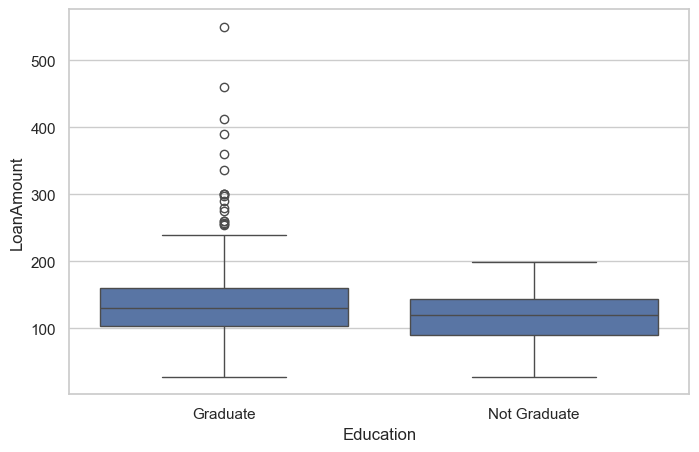

In [54]:
sns.boxplot(x='Education', y='LoanAmount', data=df)
plt.show()

--> Graduates are asking for more loans as compared to the non graduates. 

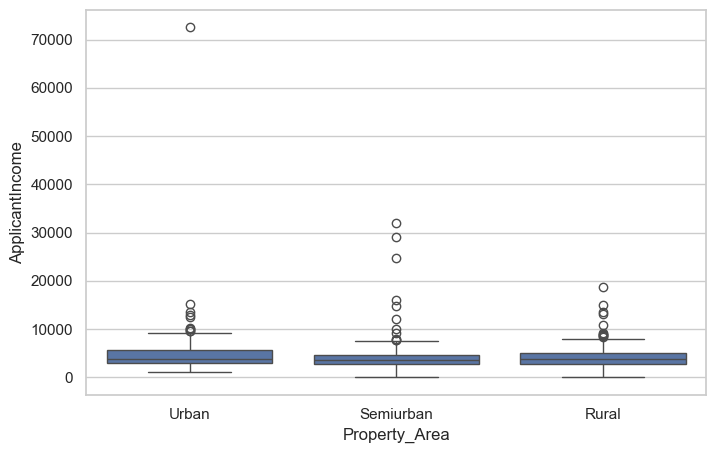

In [53]:
sns.boxplot(x='Property_Area', y='ApplicantIncome', data=df)
plt.show()

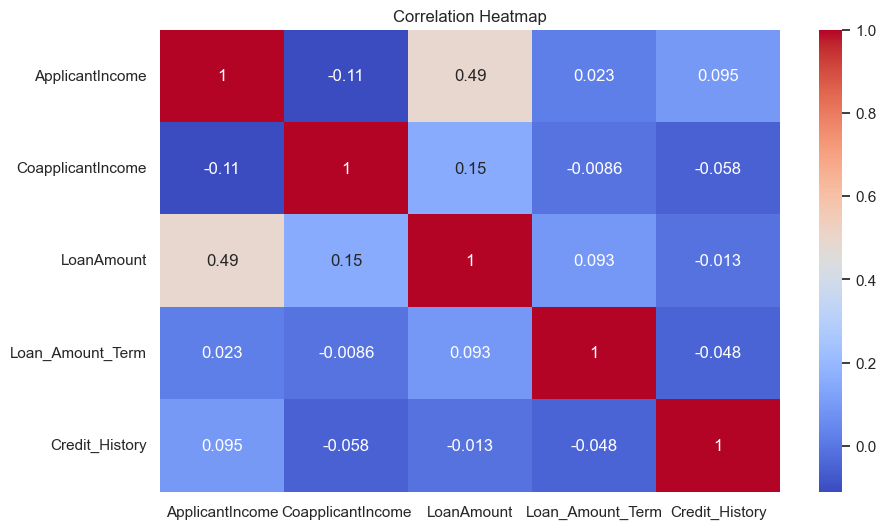

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

--> The highest correlation is 0.49 between applicant income and loan amount. This tells us that income is the most important factor deciding the loan size.

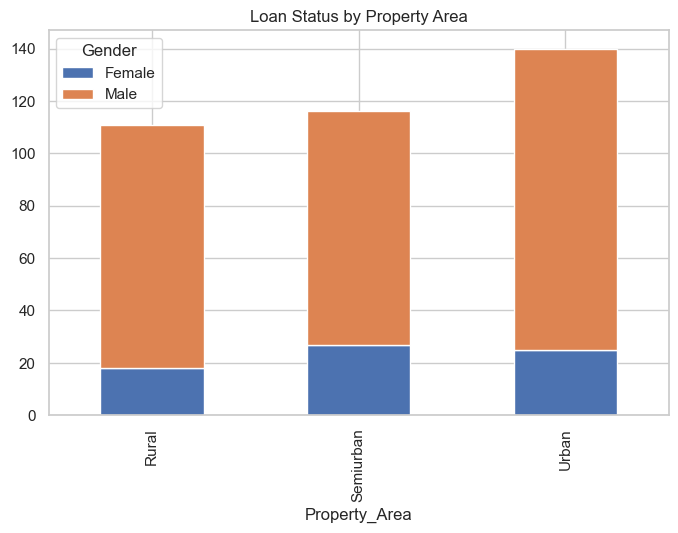

In [65]:
pd.crosstab(df['Property_Area'], df['Gender']).plot(kind='bar', stacked=True)
plt.title("Loan Status by Property Area")
plt.show()

# Overall Insights

* Most applicants have low to medium income, and only a few people earn very high income.
* The majority of loans are taken for a long time (around 360 months), which shows people prefer smaller monthly payments.
* Most applicants have a good credit history, which increases their chances of getting a loan approved.
* Male and married applicants are more in number compared to others in the dataset.
* People with higher income generally apply for higher loan amounts, but this is not always the case.
* Loan approvals are slightly higher in urban and semi-urban areas compared to rural areas.